# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately! 



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission. 
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values. 

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [42]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split. 

In [43]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?


**1.2:**  How will your solution be used?


**1.3:**  How should success (or failure) be measured?


## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [44]:
# Look at the first rows
# Purpose:
# Quickly view the structure of the dataset.
# This helps to see column names, example values,
# formatting issues, and general dataset layout.

df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.50,4.00,NaN,NaN,3.50,NaN,...,NaN,NaN,"1,998.00",NaN,NaN,"2,016.00",NaN,NaN,"60,590,630,072,012.00","1,023,282.00"
1,17052889,NaN,NaN,NaN,1.00,2.00,NaN,NaN,1.00,NaN,...,NaN,NaN,"1,967.00",1.00,NaN,"2,016.00",NaN,NaN,"61,110,010,023,006.00","464,000.00"
2,14186244,NaN,NaN,NaN,2.00,3.00,NaN,NaN,2.00,NaN,...,NaN,NaN,"1,962.00",1.00,NaN,"2,016.00",NaN,NaN,"60,590,218,022,012.00","564,778.00"
3,12177905,NaN,NaN,NaN,3.00,4.00,NaN,8.00,3.00,NaN,...,NaN,NaN,"1,970.00",NaN,NaN,"2,016.00",NaN,NaN,"60,373,001,001,006.00","145,143.00"
4,10887214,1.00,NaN,NaN,3.00,3.00,NaN,8.00,3.00,NaN,...,NaN,NaN,"1,964.00",NaN,NaN,"2,016.00",NaN,NaN,"60,371,236,012,000.00","119,407.00"


In [45]:
# Inspect dataset structure
# Purpose:
# Shows number of rows, column types, and
# non-null counts. This helps identify:
# - numeric vs categorical variables
# - missing values
# - incorrect data types


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

In [46]:
# Summary statistics
# Purpose:
# Provides descriptive statistics for numeric
# columns including:
# - mean
# - standard deviation
# - min / max
# - quartiles
# Useful for spotting outliers or unusual ranges.


df.describe()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,typeconstructiontypeid,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,assessmentyear,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
count,"77,613.00","25,007.00",207.00,50.00,"77,579.00","77,579.00",15.00,"49,809.00","76,963.00",614.00,...,223.00,"50,703.00","2,393.00",70.00,"77,309.00","17,599.00","77,579.00","2,900.00","77,332.00","77,578.00"
mean,"13,007,807.00",1.81,7.39,679.72,2.30,3.05,3.93,6.53,2.32,66.00,...,6.04,1.11,305.46,216.39,"1,968.61",1.43,"2,016.00",14.09,"60,496,673,885,752.46","490,150.59"
std,"3,518,717.01",2.97,2.73,689.70,1.00,1.14,0.26,1.72,0.98,0.00,...,0.56,1.17,238.74,190.18,23.79,0.54,0.00,2.18,"1,533,339,296,950.52","653,797.86"
min,"10,711,855.00",1.00,2.00,38.00,0.00,0.00,3.00,1.00,1.00,66.00,...,4.00,1.00,11.00,12.00,"1,824.00",1.00,"2,016.00",3.00,"60,371,011,101,000.00","1,000.00"
25%,"11,538,209.00",1.00,7.00,273.00,2.00,2.00,4.00,6.00,2.00,66.00,...,6.00,1.00,170.00,61.50,"1,953.00",1.00,"2,016.00",14.00,"60,373,109,004,005.00","206,898.50"
50%,"12,530,044.00",1.00,7.00,515.00,2.00,3.00,4.00,6.00,2.00,66.00,...,6.00,1.00,250.00,164.50,"1,970.00",1.00,"2,016.00",15.00,"60,376,032,001,510.50","358,878.50"
75%,"14,211,010.00",1.00,7.00,796.50,3.00,4.00,4.00,8.00,3.00,66.00,...,6.00,1.00,364.00,310.50,"1,987.00",2.00,"2,016.00",15.00,"60,590,423,251,007.00","569,000.00"
max,"167,689,317.00",13.00,21.00,"3,560.00",18.00,16.00,4.00,12.00,18.00,66.00,...,13.00,237.00,"3,191.00",868.00,"2,016.00",6.00,"2,016.00",99.00,"483,030,105,084,015.00","49,061,236.00"


In [47]:
# 4. Unique value counts
# Purpose:
# Counts the number of distinct (unique) values
# in each column of the dataset.
#
# Provides:
# - Number of unique entries per column
#
# Useful for:
# - Identifying categorical vs numerical features
# - Detecting high-cardinality variables
# - Spotting columns with little variation (low uniqueness)
# - Understanding potential features for encoding


df.nunique()

parcelid                        77414
airconditioningtypeid               5
architecturalstyletypeid            5
basementsqft                       43
bathroomcnt                        22
bedroomcnt                         16
buildingclasstypeid                 2
buildingqualitytypeid              12
calculatedbathnbr                  21
decktypeid                          1
finishedfloor1squarefeet         1787
calculatedfinishedsquarefeet     4972
finishedsquarefeet12             4868
finishedsquarefeet13               13
finishedsquarefeet15             1724
finishedsquarefeet50             1807
finishedsquarefeet6               350
fips                                3
fireplacecnt                        5
fullbathcnt                        13
garagecarcnt                       14
garagetotalsqft                   839
hashottuborspa                      1
heatingorsystemtypeid              10
latitude                        64038
longitude                       62461
lotsizesquar

In [48]:
summary = pd.DataFrame({"Column": df.columns, "Dtype": df.dtypes, "Unique Values": df.nunique()})

In [49]:
# defining type of categorical variables

def classify_column(col):
    col_lower = col.lower()
    
    if "id" in col_lower:
        return "ID"
    elif any(x in col_lower for x in ["cnt", "nbr", "number"]):
        return "Discrete Numerical"
    elif df[col].dtype == "object":
        return "Categorical"
    elif df[col].nunique() <= 20 and "sqft" not in col_lower and "year" not in col_lower:
        return "Categorical (Numeric)"
    else:
        return "Continuous"


summary["Type"] = summary["Column"].apply(classify_column)

In [50]:
# document the types and counts of variables
# numeric categorical - Categories that happen to be stored as numbers but aren't really quantities
# discrete numerical category - Can only take specific whole number values, usually counts, 
# Examples from dataset: bedroomcnt, bathroomcnt, garagecarcnt, fireplacecnt


type_counts = summary["Type"].value_counts()

print("Number of Continuous variables:", type_counts.get("Continuous", 0))
print("Number of Discrete Numerical variables:", type_counts.get("Discrete Numerical", 0))
print("Number of Categorical variables:", type_counts.get("Categorical", 0))
print("Number of Categorical (Numeric) variables:", type_counts.get("Categorical (Numeric)", 0))
print("Number of ID variables:", type_counts.get("ID", 0))

Number of Continuous variables: 19
Number of Discrete Numerical variables: 12
Number of Categorical variables: 5
Number of Categorical (Numeric) variables: 2
Number of ID variables: 17


The Zillow housing dataset contains 55 variables in total, which can be divided into five types. There are 19 continuous numerical variables, such as calculatedfinishedsquarefeet, lotsizesquarefeet, and taxvaluedollarcnt, which represent measurable quantities that can take any value. There are 12 discrete numerical variables, such as bedroomcnt and bathroomcnt, that represent whole-number counts. There are 5 true categorical variables stored as text, and 2 categorical variables stored numerically, such as fips, which represent group codes rather than a meaningful quantity. Finally, there are 17 ID variables such as parcelid and regionidzip, which serve only as identifiers and should be excluded from modeling.


In [51]:
# Identify the variable names for each type

for var_type in ['Continuous', 'Discrete Numerical', 'Categorical', 'Categorical (Numeric)', 'ID']:
    cols = summary[summary['Type'] == var_type]['Column'].tolist()
    print(f"\n{var_type} variables ({len(cols)}):")
    print(cols)


Continuous variables (19):
['basementsqft', 'finishedfloor1squarefeet', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedsquarefeet6', 'garagetotalsqft', 'latitude', 'longitude', 'lotsizesquarefeet', 'poolsizesum', 'rawcensustractandblock', 'yardbuildingsqft17', 'yardbuildingsqft26', 'yearbuilt', 'assessmentyear', 'taxdelinquencyyear', 'censustractandblock']

Discrete Numerical variables (12):
['bathroomcnt', 'bedroomcnt', 'calculatedbathnbr', 'fireplacecnt', 'fullbathcnt', 'garagecarcnt', 'poolcnt', 'roomcnt', 'threequarterbathnbr', 'unitcnt', 'numberofstories', 'taxvaluedollarcnt']

Categorical variables (5):
['hashottuborspa', 'propertycountylandusecode', 'propertyzoningdesc', 'fireplaceflag', 'taxdelinquencyflag']

Categorical (Numeric) variables (2):
['finishedsquarefeet13', 'fips']

ID variables (17):
['parcelid', 'airconditioningtypeid', 'architecturalstyletypeid', 'buildingclasstypeid', 'buildingqualitytypeid', 'd

Categorical variables were identified using both data types and unique value counts. Object-type variables were treated as "true categorical" features (5), while some numerical variables (2) with limited distinct values were also considered categorical for modeling purposes.

In [52]:
# exploring categorical variables

true_categorical = [
    'hashottuborspa',
    'propertycountylandusecode',
    'propertyzoningdesc',
    'fireplaceflag',
    'taxdelinquencyflag'
]

for col in true_categorical:
    print(f"\n=== {col} ===")
    print("Unique values:", df[col].nunique())
    print("Missing values:", df[col].isnull().sum())
    print(df[col].value_counts(dropna=False))


=== hashottuborspa ===
Unique values: 1
Missing values: 76074
hashottuborspa
NaN     76074
True     1539
Name: count, dtype: int64

=== propertycountylandusecode ===
Unique values: 75
Missing values: 34
propertycountylandusecode
0100    26782
122     13067
010C     8838
0101     6413
34       4932
        ...  
030G        1
105         1
020G        1
020M        1
020E        1
Name: count, Length: 76, dtype: int64

=== propertyzoningdesc ===
Unique values: 1907
Missing values: 27137
propertyzoningdesc
NaN           27137
LAR1           6766
LAR3           2450
LARS           1394
LBR1N          1225
              ...  
LVPR3D-A1-        1
WV RPD56*         1
POC4-R3200        1
SFR2              1
SLR16500*         1
Name: count, Length: 1908, dtype: int64

=== fireplaceflag ===
Unique values: 1
Missing values: 77441
fireplaceflag
NaN     77441
True      172
Name: count, dtype: int64

=== taxdelinquencyflag ===
Unique values: 1
Missing values: 74713
taxdelinquencyflag
NaN    74713


In [53]:
# Looking at missing values

df.isnull()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,False,True,True,True,False,False,True,True,False,True,...,True,True,False,True,True,False,True,True,False,False
1,False,True,True,True,False,False,True,True,False,True,...,True,True,False,False,True,False,True,True,False,False
2,False,True,True,True,False,False,True,True,False,True,...,True,True,False,False,True,False,True,True,False,False
3,False,True,True,True,False,False,True,False,False,True,...,True,True,False,True,True,False,True,True,False,False
4,False,False,True,True,False,False,True,False,False,True,...,True,True,False,True,True,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77608,False,False,True,True,False,False,True,False,False,True,...,True,True,False,True,True,False,True,True,False,False
77609,False,True,True,True,False,False,True,False,False,True,...,True,True,False,True,True,False,True,True,False,False
77610,False,True,True,True,False,False,True,True,False,True,...,False,True,False,False,True,False,True,True,False,False
77611,False,False,True,True,False,False,True,False,False,True,...,True,True,False,True,True,False,True,True,False,False


In [54]:
# Identify % of variables with greater than 60% missing variables (next code looks specifically at 70% for cleaning)

missing_pct = df.isnull().mean()

# Filter columns with >70% missing
high_missing = missing_pct[missing_pct > 0.60]

# Sort
high_missing = high_missing.sort_values(ascending=False)

print("Variables with >80% missing:\n")
print(high_missing)

Variables with >80% missing:

buildingclasstypeid        1.00
finishedsquarefeet13       1.00
basementsqft               1.00
storytypeid                1.00
yardbuildingsqft26         1.00
fireplaceflag              1.00
architecturalstyletypeid   1.00
typeconstructiontypeid     1.00
finishedsquarefeet6        1.00
pooltypeid10               0.99
decktypeid                 0.99
poolsizesum                0.99
pooltypeid2                0.99
hashottuborspa             0.98
yardbuildingsqft17         0.97
taxdelinquencyflag         0.96
taxdelinquencyyear         0.96
finishedsquarefeet15       0.96
finishedsquarefeet50       0.92
finishedfloor1squarefeet   0.92
fireplacecnt               0.89
threequarterbathnbr        0.87
pooltypeid7                0.81
poolcnt                    0.79
numberofstories            0.77
airconditioningtypeid      0.68
garagecarcnt               0.67
garagetotalsqft            0.67
regionidneighborhood       0.60
dtype: float64


In [55]:
# There is a jump from 77% to 68%, so natural break for assessing clean at 70% or more missing

# Calculate % missing for each column
missing_pct = df.isnull().mean()

# Filter columns with >70% missing
high_missing = missing_pct[missing_pct > 0.7]

# Sort
high_missing = high_missing.sort_values(ascending=False)

print("Variables with >70% missing:\n")
print(high_missing)

Variables with >70% missing:

buildingclasstypeid        1.00
finishedsquarefeet13       1.00
basementsqft               1.00
storytypeid                1.00
yardbuildingsqft26         1.00
fireplaceflag              1.00
architecturalstyletypeid   1.00
typeconstructiontypeid     1.00
finishedsquarefeet6        1.00
pooltypeid10               0.99
decktypeid                 0.99
poolsizesum                0.99
pooltypeid2                0.99
hashottuborspa             0.98
yardbuildingsqft17         0.97
taxdelinquencyflag         0.96
taxdelinquencyyear         0.96
finishedsquarefeet15       0.96
finishedfloor1squarefeet   0.92
finishedsquarefeet50       0.92
fireplacecnt               0.89
threequarterbathnbr        0.87
pooltypeid7                0.81
poolcnt                    0.79
numberofstories            0.77
dtype: float64


In [56]:
# just a listing of the variables with high missing count, in list form

print(list(high_missing.index))

['buildingclasstypeid', 'finishedsquarefeet13', 'basementsqft', 'storytypeid', 'yardbuildingsqft26', 'fireplaceflag', 'architecturalstyletypeid', 'typeconstructiontypeid', 'finishedsquarefeet6', 'pooltypeid10', 'decktypeid', 'poolsizesum', 'pooltypeid2', 'hashottuborspa', 'yardbuildingsqft17', 'taxdelinquencyflag', 'taxdelinquencyyear', 'finishedsquarefeet15', 'finishedfloor1squarefeet', 'finishedsquarefeet50', 'fireplacecnt', 'threequarterbathnbr', 'pooltypeid7', 'poolcnt', 'numberofstories']



A substantial number of variables in the dataset have significant missing values, with 8 variables at 100% missing, and 25 variables having more than 70% of values missing. These variables would unreliable information for modeling and are suggested to be dropped. 

In [57]:
# Check for low variance in variable responses, responses with less than 1 value
# finds columns where every single row has the same value (or the column is completely empty). 
# Zero variation, not helpful for modeling

low_variance = df.nunique()[df.nunique() <= 1]

print("Low variance (constant) variables:")
print(low_variance)

Low variance (constant) variables:
decktypeid            1
hashottuborspa        1
poolcnt               1
pooltypeid10          1
pooltypeid2           1
pooltypeid7           1
storytypeid           1
fireplaceflag         1
assessmentyear        1
taxdelinquencyflag    1
dtype: int64


In [58]:

# THis finds columns where 95% or more of rows have the same value. Not completely constant, but close enough to be questioned for use

low_variance_cols = []

for col in df.columns:
    top_freq = df[col].value_counts(normalize=True, dropna=False).values[0]
    
    if top_freq > 0.95:
        low_variance_cols.append(col)

print("Near-constant variables (>95% same value):")
print(low_variance_cols)

Near-constant variables (>95% same value):
['architecturalstyletypeid', 'basementsqft', 'buildingclasstypeid', 'decktypeid', 'finishedsquarefeet13', 'finishedsquarefeet15', 'finishedsquarefeet6', 'hashottuborspa', 'poolsizesum', 'pooltypeid10', 'pooltypeid2', 'storytypeid', 'typeconstructiontypeid', 'yardbuildingsqft17', 'yardbuildingsqft26', 'fireplaceflag', 'assessmentyear', 'taxdelinquencyflag', 'taxdelinquencyyear']


In [59]:
# VarianceThreshold (0.01) is used to identify features with very low variability.
# A threshold of 0.01 indicates the values are nearly constant (e.g., ~99% the same).
# At this stage, variables are only being identified for potential removal, not dropped.


from sklearn.feature_selection import VarianceThreshold

# Only numeric data
num_df = df.select_dtypes(include=['number'])

selector = VarianceThreshold(threshold=0.01)
selector.fit(num_df)

low_variance = num_df.columns[~selector.get_support()]

print("Low variance numeric variables:")
print(list(low_variance))

Low variance numeric variables:
['decktypeid', 'poolcnt', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7', 'storytypeid', 'assessmentyear']


In [60]:
# Suggested columns to drop to include:
# 1. ID variables
# 2. Near-constant variables (>95% same value)
# 3. High missingness variables 
# 4. Redundant variables (e.g. multiple sqft columns that measure similar things)

#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

In [61]:
'hashottuborspa', 'propertycountylandusecode', 'propertyzoningdesc', 'fireplaceflag', 'taxdelinquencyflag'

('hashottuborspa',
 'propertycountylandusecode',
 'propertyzoningdesc',
 'fireplaceflag',
 'taxdelinquencyflag')

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly. 


Region and internal identifier variables: These are administrative id's used by county records and census systems. They are based on geography, redundantly with lat/long and region IDs.
- regionidzip, regionidcity, and regionidneighborhood
- 'parcelid', 'rawcensustractandblock', 'censustractandblock', 'fips', 'propertycountylandusecode', 'assessmentyear'

Redundant square footage variables: For variables that output square footage of different aspects, likely the three best to keep are ('calculatedfinishedsquarefeet', 'lotsizesquarefeet', 'garagetotalsqft'), These variables could be removed: 'finishedsquarefeet12', 'finishedsquarefeet13', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedsquarefeet6'. This will help with co-linearity.

Redundant bathroom counts: 'bathroomcnt' is an aggregate variable and what homebuyers looking for, these are redundant 'calculatedbathnbr', 'fullbathcnt', 'threequarterbathnbr'

Redundant pool/spa: the variables 'poolcnt' and 'poolsizesum' account for both presence and size, so these variables are redundant: 'pooltypeid10', 'pooltypeid2', 'pooltypeid7', 'hashottuborspa'

Tax/delinquency: these variables would not have any impact on tax assessed value, more related to risk or distressed sales: 'taxdelinquencyflag', 'taxdelinquencyyear'





**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example. 

Missing values:
- variables with >70% missing values, as they would require significant imputation that could introduce noise

- ['buildingclasstypeid', 'finishedsquarefeet13', 'basementsqft', 'storytypeid', 'yardbuildingsqft26', 'fireplaceflag', 'architecturalstyletypeid', 'typeconstructiontypeid', 'finishedsquarefeet6', 'pooltypeid10', 'decktypeid', 'poolsizesum', 'pooltypeid2', 'hashottuborspa', 'yardbuildingsqft17', 'taxdelinquencyflag', 'taxdelinquencyyear', 'finishedsquarefeet15', 'finishedfloor1squarefeet', 'finishedsquarefeet50', 'fireplacecnt', 'threequarterbathnbr', 'pooltypeid7', 'poolcnt', 'numberofstories']

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example. 

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

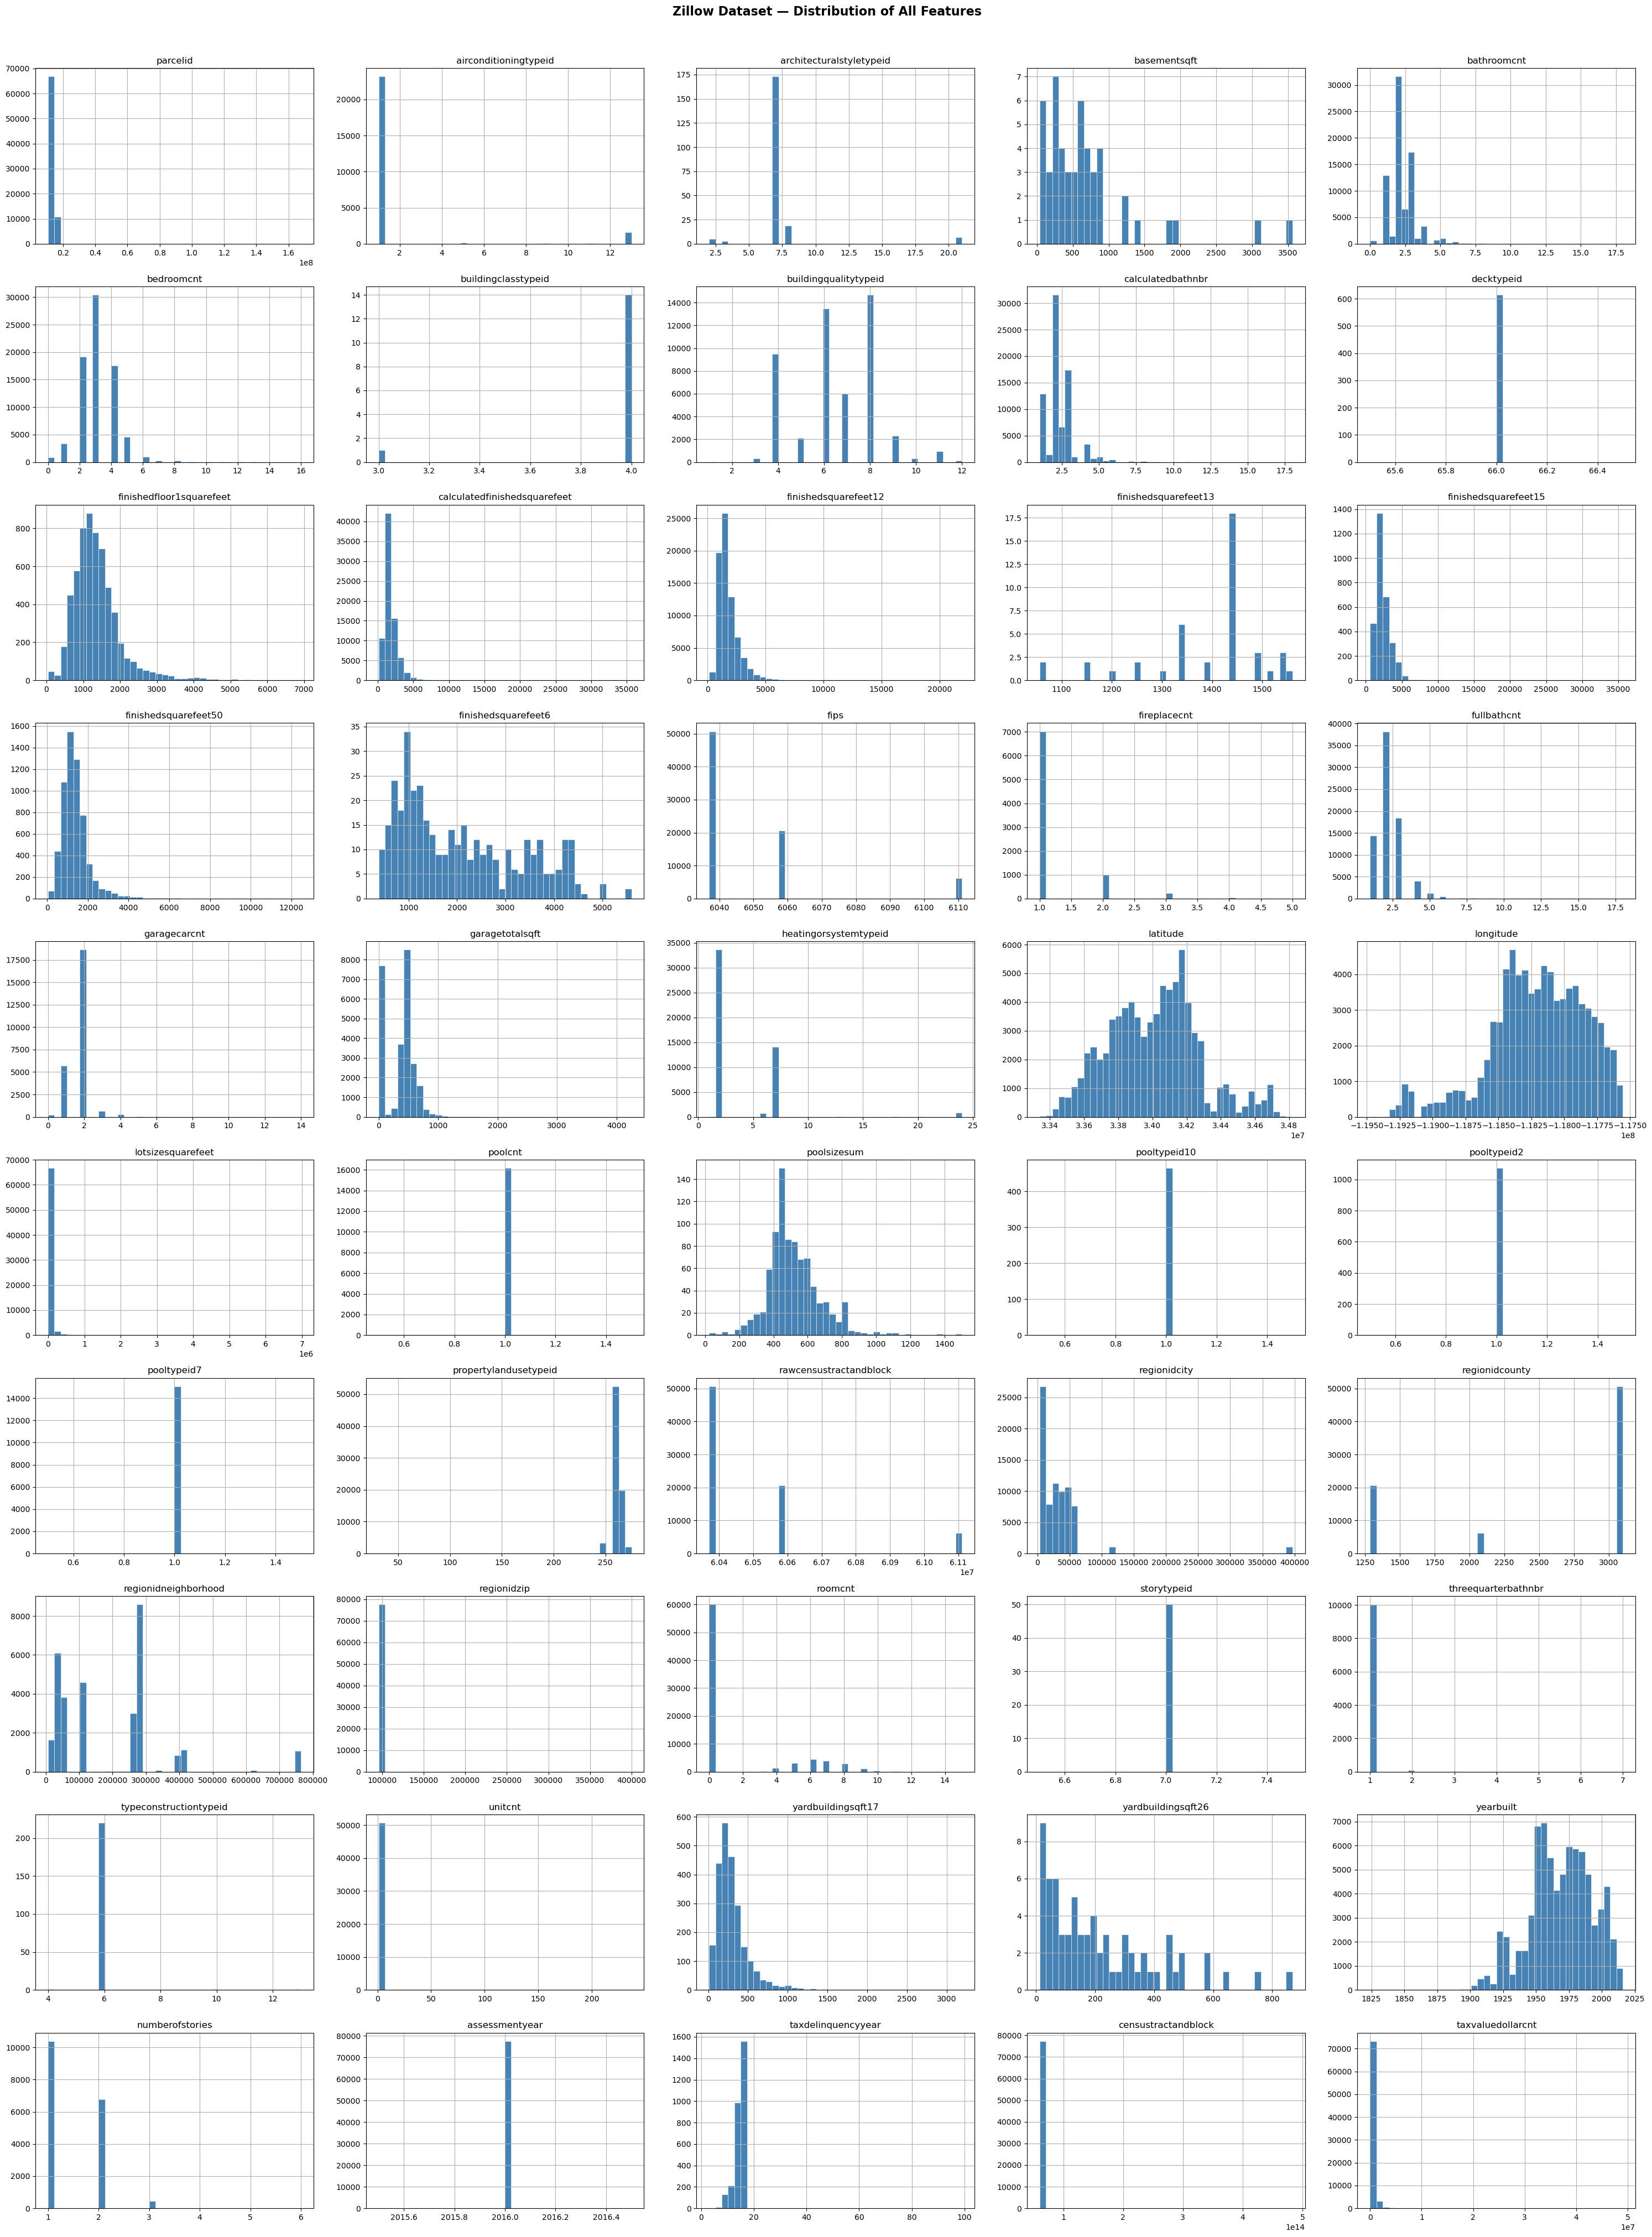

In [62]:

# Overview: Histograms for ALL Features using df.hist()


ax = df.hist(figsize=(30, 40), layout=(-1, 5), bins=40, 
             edgecolor='white', linewidth=0.4, color='steelblue')

plt.suptitle('Zillow Dataset — Distribution of All Features', 
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('zillow_all_features.png', dpi=150, bbox_inches='tight')
plt.show()

Plotting 44 numeric features...


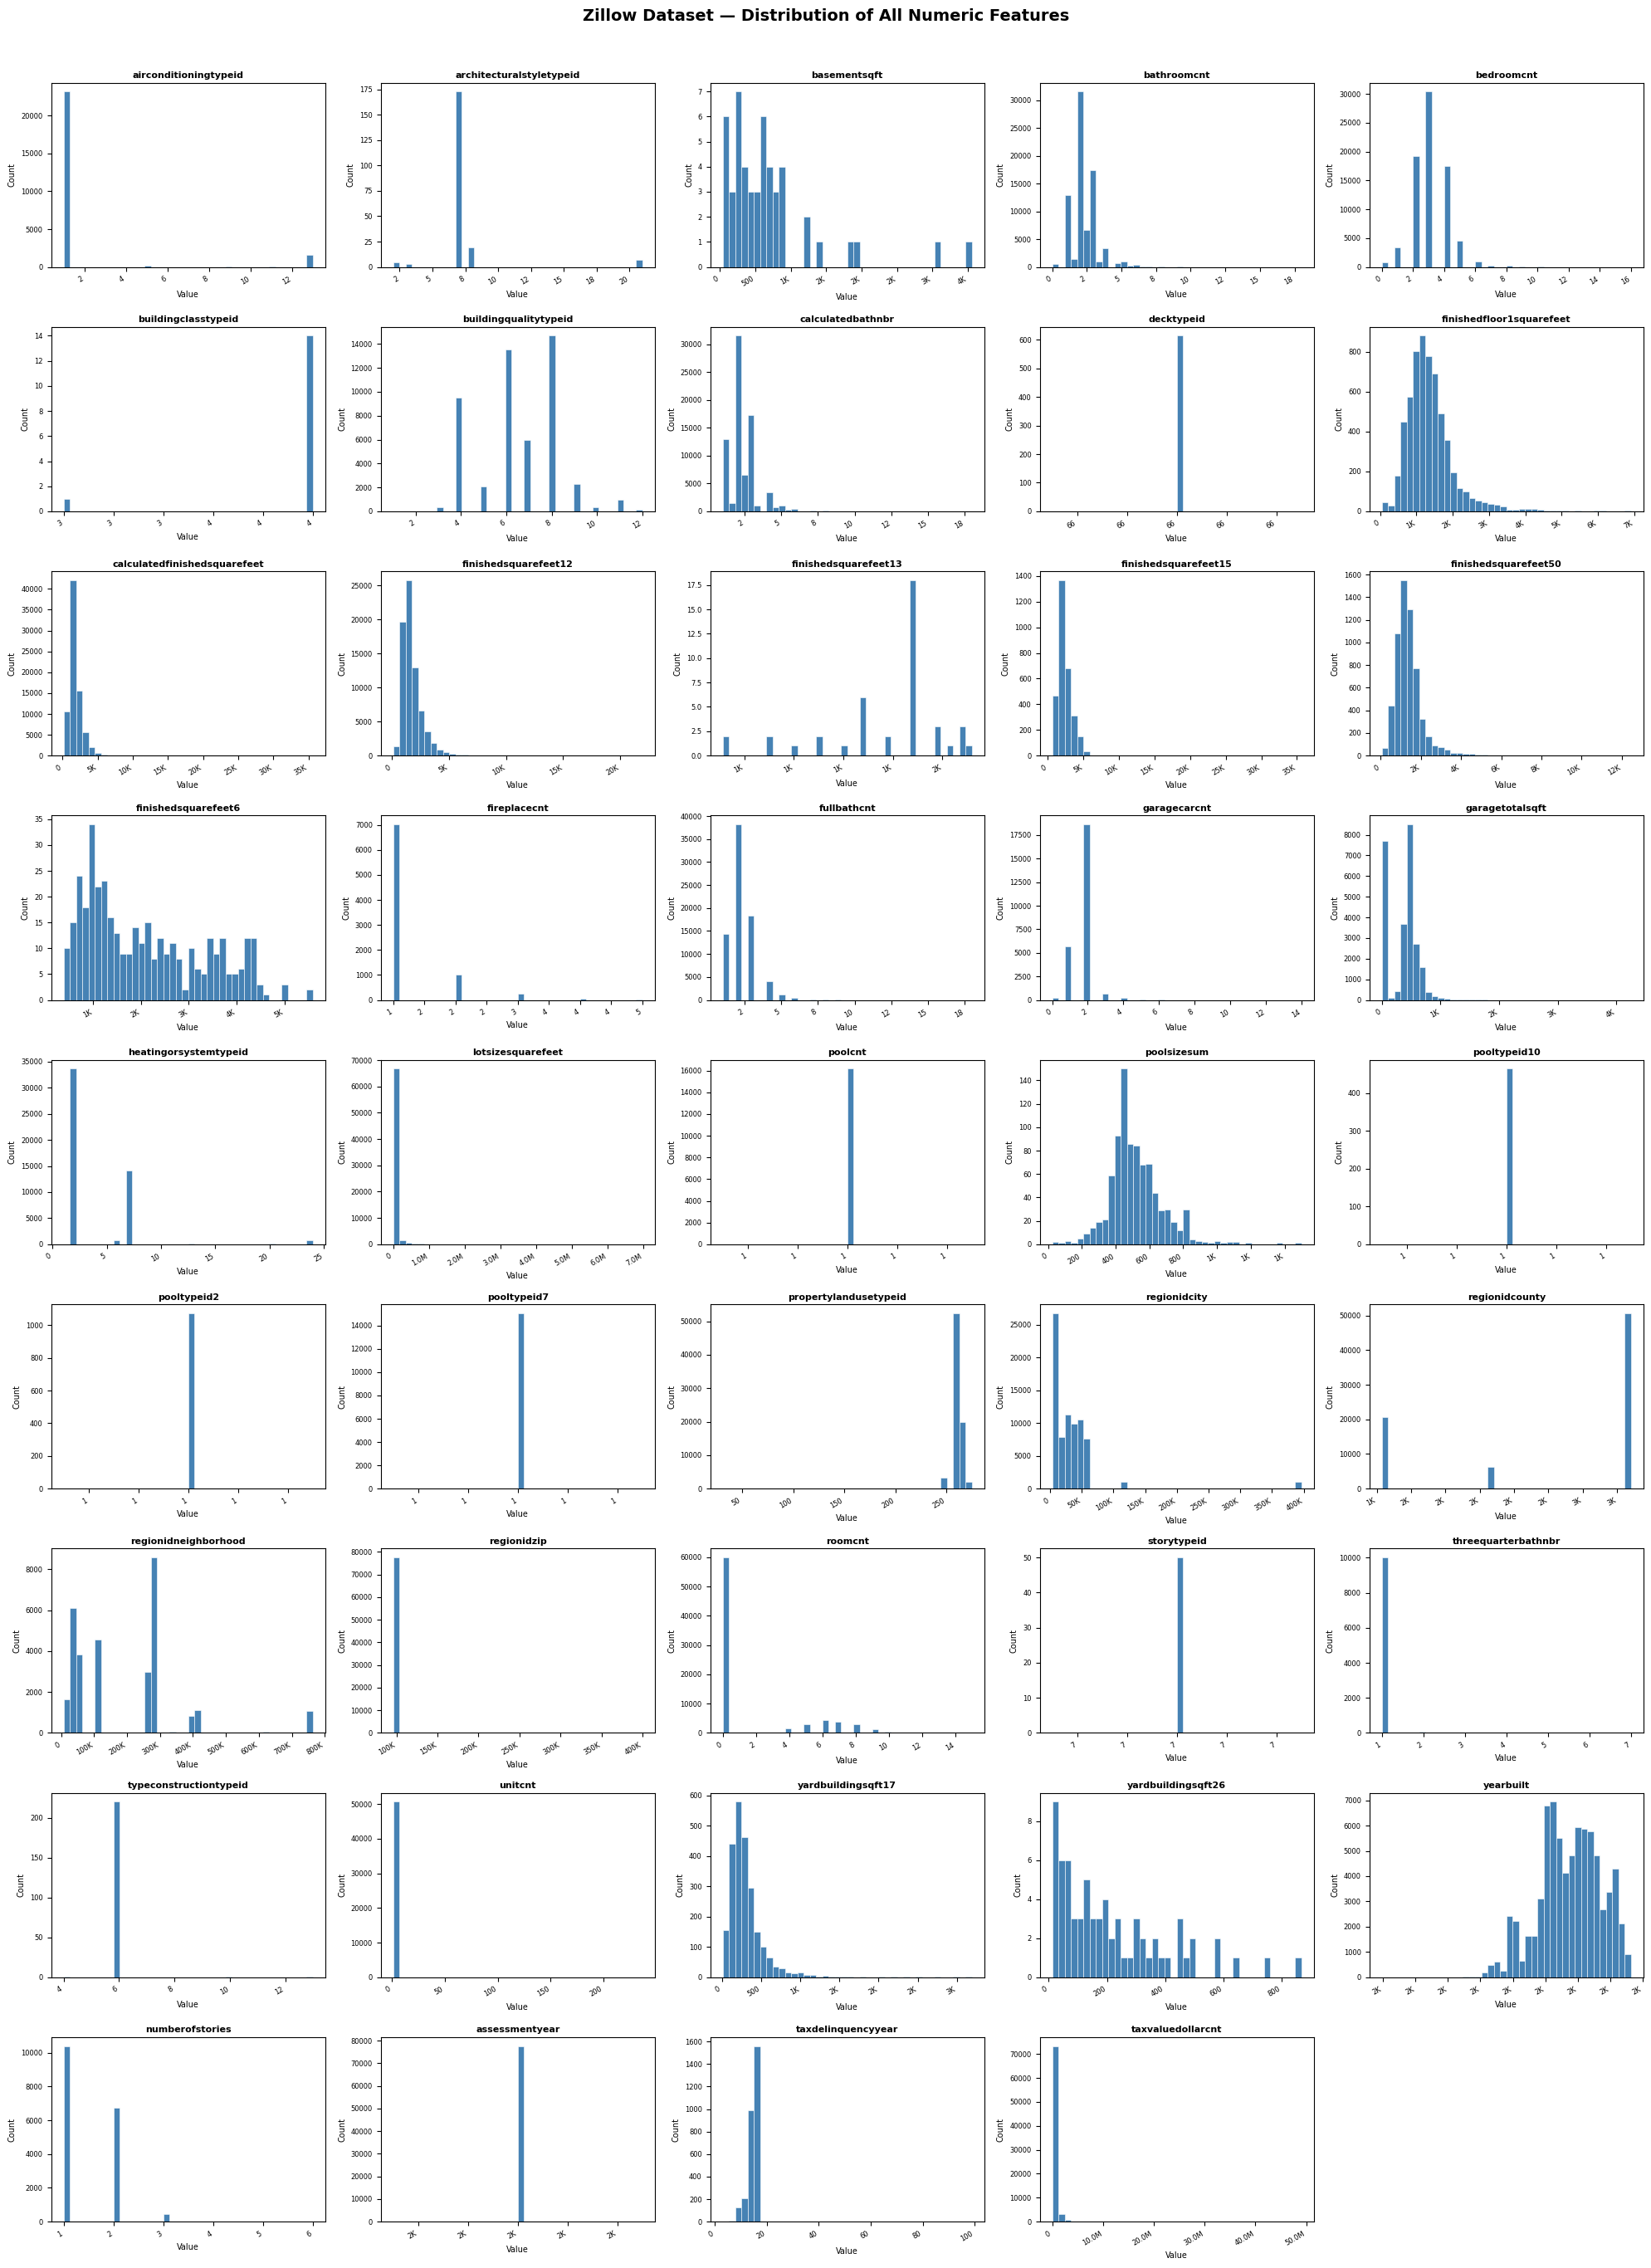

Saved: zillow_all_features.png


In [63]:

# Overview: Histograms for ALL Numeric Features


# Select only numeric columns (drop ID-like columns)
exclude_cols = ['parcelid', 'rawcensustractandblock', 'censustractandblock',
                'latitude', 'longitude', 'fips']
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in exclude_cols]

print(f"Plotting {len(numeric_cols)} numeric features...")

# Dynamic grid layout
n_cols = 5
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    data = df[col].dropna()

    ax.hist(data, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
    ax.set_title(col, fontsize=8, fontweight='bold', pad=4)
    ax.set_xlabel('Value', fontsize=7)
    ax.set_ylabel('Count', fontsize=7)
    ax.tick_params(axis='both', labelsize=6)

    # Format x-axis to avoid clutter on large numbers
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e6:.1f}M' if abs(x) >= 1e6 else
                      f'{x/1e3:.0f}K' if abs(x) >= 1e3 else f'{x:.0f}'
    ))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# Hide any unused subplot panels
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Zillow Dataset — Distribution of All Numeric Features',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('zillow_all_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: zillow_all_features.png")


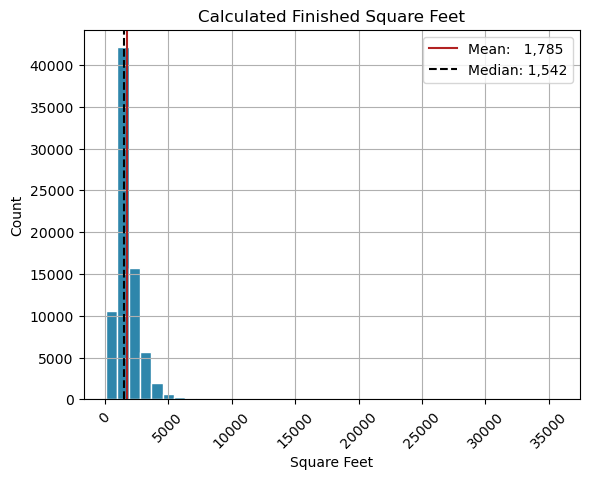

In [64]:
# Histogram for choice of three plots: 
# PLot 1: 'calculatedfinishedsquarefeet'

mean_val   = df['calculatedfinishedsquarefeet'].mean()
median_val = df['calculatedfinishedsquarefeet'].median()

df['calculatedfinishedsquarefeet'].hist(bins=40, color='#2E86AB', edgecolor='white')
plt.axvline(mean_val,   color='firebrick', linestyle='-',  linewidth=1.5, label=f'Mean:   {mean_val:,.0f}')
plt.axvline(median_val, color='black',     linestyle='--', linewidth=1.5, label=f'Median: {median_val:,.0f}')
plt.title('Calculated Finished Square Feet')
plt.xlabel('Square Feet')
plt.ylabel('Count')
plt.ticklabel_format(axis='x', style='plain')
plt.xticks(rotation=45)
plt.legend()
plt.show()

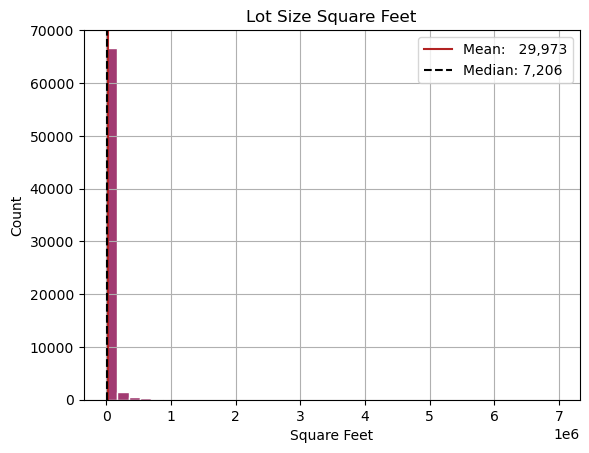

In [65]:
# Histogram for choice of plots:
# PLot 2: lotsizesquarefeet

mean_val   = df['lotsizesquarefeet'].mean()
median_val = df['lotsizesquarefeet'].median()

df['lotsizesquarefeet'].hist(bins=40, color='#A23B72', edgecolor='white')
plt.axvline(mean_val,   color='firebrick', linestyle='-',  linewidth=1.5, label=f'Mean:   {mean_val:,.0f}')
plt.axvline(median_val, color='black',     linestyle='--', linewidth=1.5, label=f'Median: {median_val:,.0f}')
plt.title('Lot Size Square Feet')
plt.xlabel('Square Feet')
plt.ylabel('Count')
plt.legend()
plt.show()

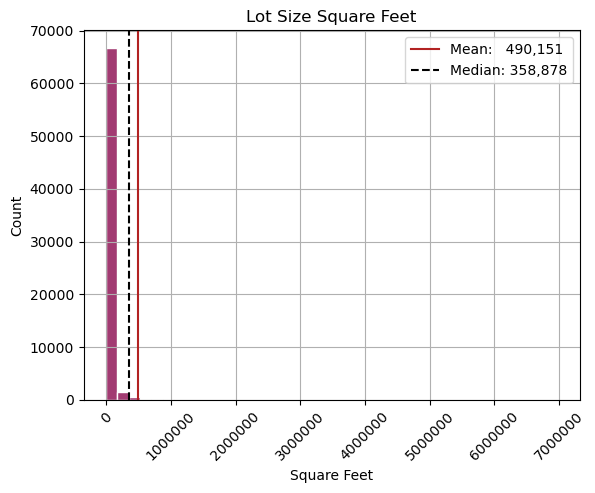

In [66]:
# Histogram for choice of plots (target): 'taxvaluedollarcnt'
# Plot 3: taxvaluedollarcnt
# taxvaluedollarcnt
mean_val   = df['taxvaluedollarcnt'].mean()
median_val = df['taxvaluedollarcnt'].median()

df['lotsizesquarefeet'].hist(bins=40, color='#A23B72', edgecolor='white')
plt.axvline(mean_val,   color='firebrick', linestyle='-',  linewidth=1.5, label=f'Mean:   {mean_val:,.0f}')
plt.axvline(median_val, color='black',     linestyle='--', linewidth=1.5, label=f'Median: {median_val:,.0f}')
plt.title('Lot Size Square Feet')
plt.xlabel('Square Feet')
plt.ylabel('Count')
plt.ticklabel_format(axis='x', style='plain')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [67]:
pd.set_option('display.float_format', '{:,.2f}'.format)

print(df['lotsizesquarefeet'].describe())
print(df['calculatedfinishedsquarefeet'].describe())
print(df['taxvaluedollarcnt'].describe())

count      69,321.00
mean       29,973.44
std       123,305.05
min           236.00
25%         5,700.00
50%         7,206.00
75%        11,837.00
max     6,971,010.00
Name: lotsizesquarefeet, dtype: float64
count   77,378.00
mean     1,784.94
std        954.25
min        128.00
25%      1,182.00
50%      1,542.00
75%      2,112.00
max     35,640.00
Name: calculatedfinishedsquarefeet, dtype: float64
count       77,578.00
mean       490,150.59
std        653,797.86
min          1,000.00
25%        206,898.50
50%        358,878.50
75%        569,000.00
max     49,061,236.00
Name: taxvaluedollarcnt, dtype: float64


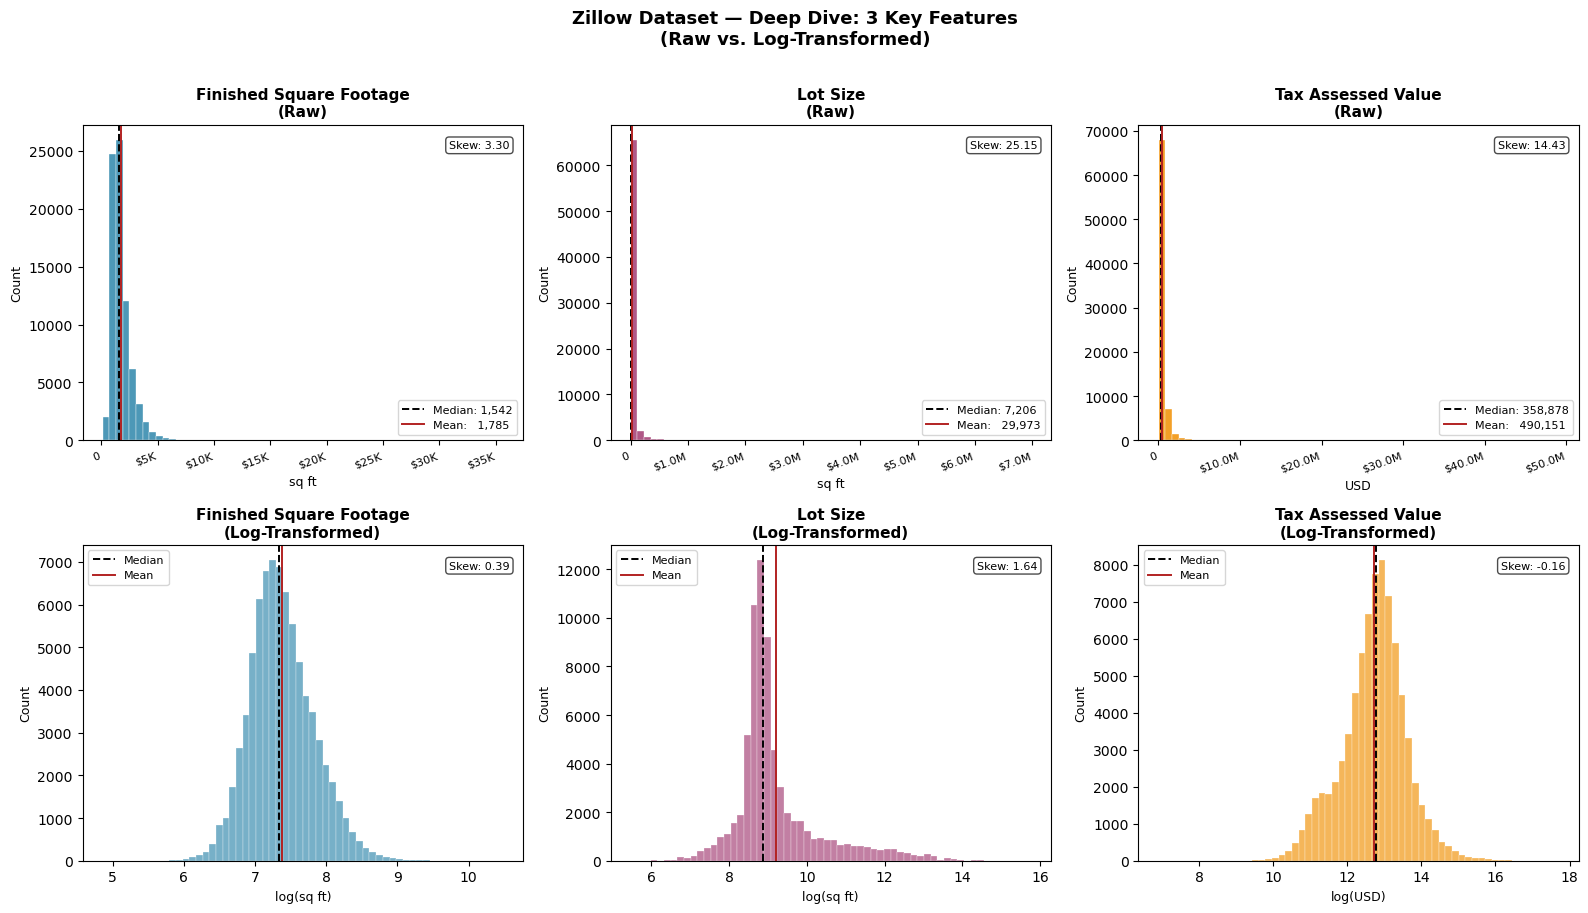

Saved: zillow_three_features.png


In [68]:

# Histogram of log conversion of 2 selected features and the target


features = {
    'calculatedfinishedsquarefeet': {
        'label': 'Finished Square Footage',
        'unit': 'sq ft',
        'color': '#2E86AB'
    },
    'lotsizesquarefeet': {
        'label': 'Lot Size',
        'unit': 'sq ft',
        'color': '#A23B72'
    },
    'taxvaluedollarcnt': {
        'label': 'Tax Assessed Value',
        'unit': 'USD',
        'color': '#F18F01'
    }
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for col_idx, (col, meta) in enumerate(features.items()):
    data = df[col].dropna()

    # ── Row 1: Raw distribution ──────────────────────────────
    ax = axes[0, col_idx]
    ax.hist(data, bins=60, color=meta['color'], edgecolor='white', linewidth=0.3,
            alpha=0.85)

    # Mark median and mean
    median_val = data.median()
    mean_val   = data.mean()
    ax.axvline(median_val, color='black',     linestyle='--', linewidth=1.4,
               label=f'Median: {median_val:,.0f}')
    ax.axvline(mean_val,   color='firebrick', linestyle='-',  linewidth=1.4,
               label=f'Mean:   {mean_val:,.0f}')

    ax.set_title(f'{meta["label"]}\n(Raw)', fontsize=11, fontweight='bold')
    ax.set_xlabel(meta['unit'], fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'${x/1e6:.1f}M' if (meta['unit']=='USD' and abs(x)>=1e6) else
                      f'${x/1e3:.0f}K' if (meta['unit']=='USD' and abs(x)>=1e3) else
                      f'{x/1e3:.0f}K'  if abs(x)>=1e3 else f'{x:.0f}'
    ))
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)

    # ── Row 2: Log-transformed distribution ──────────────────
    ax2 = axes[1, col_idx]
    log_data = np.log1p(data[data > 0])  # log1p handles near-zero values safely
    ax2.hist(log_data, bins=60, color=meta['color'], edgecolor='white',
             linewidth=0.3, alpha=0.65)
    ax2.axvline(log_data.median(), color='black',     linestyle='--', linewidth=1.4,
                label='Median')
    ax2.axvline(log_data.mean(),   color='firebrick', linestyle='-',  linewidth=1.4,
                label='Mean')
    ax2.set_title(f'{meta["label"]}\n(Log-Transformed)', fontsize=11, fontweight='bold')
    ax2.set_xlabel(f'log({meta["unit"]})', fontsize=9)
    ax2.set_ylabel('Count', fontsize=9)
    ax2.legend(fontsize=8)

    # Annotation: skewness
    skew_raw = data.skew()
    skew_log = log_data.skew()
    ax.text(0.97, 0.95, f'Skew: {skew_raw:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    ax2.text(0.97, 0.95, f'Skew: {skew_log:.2f}', transform=ax2.transAxes,
             ha='right', va='top', fontsize=8,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

fig.suptitle('Zillow Dataset — Deep Dive: 3 Key Features\n(Raw vs. Log-Transformed)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('zillow_three_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: zillow_three_features.png")

In [69]:
for col in ['calculatedfinishedsquarefeet', 'lotsizesquarefeet', 'taxvaluedollarcnt']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR
    n_outliers = df[(df[col] > upper) | (df[col] < lower)][col].count()
    mean_val   = df[col].mean()
    median_val = df[col].median()
    print(f"{col}")
    print(f"  Mean:           {mean_val:,.0f}")
    print(f"  Median:         {median_val:,.0f}")
    print(f"  Lower bound:    {lower:,.0f}")
    print(f"  Upper bound:    {upper:,.0f}")
    print(f"  No. outliers:   {n_outliers} ({n_outliers/df[col].count()*100:.1f}%)\n")

calculatedfinishedsquarefeet
  Mean:           1,785
  Median:         1,542
  Lower bound:    -213
  Upper bound:    3,507
  No. outliers:   4006 (5.2%)

lotsizesquarefeet
  Mean:           29,973
  Median:         7,206
  Lower bound:    -3,506
  Upper bound:    21,042
  No. outliers:   11408 (16.5%)

taxvaluedollarcnt
  Mean:           490,151
  Median:         358,878
  Lower bound:    -336,254
  Upper bound:    1,112,152
  No. outliers:   5186 (6.7%)



In [70]:
# see the worst offenders
print(df['calculatedfinishedsquarefeet'].nlargest(10))

37742   35,640.00
7199    21,929.00
24744   20,612.00
8556    18,654.00
5113    18,197.00
71758   17,245.00
41672   15,450.00
64668   14,829.00
40078   13,598.00
21703   12,616.00
Name: calculatedfinishedsquarefeet, dtype: float64


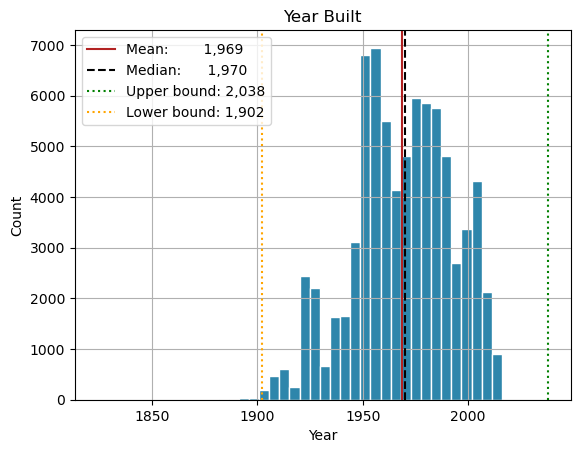

In [71]:
# Histogram of feature: yearbuilt 
mean_val   = df['yearbuilt'].mean()
median_val = df['yearbuilt'].median()
Q1         = df['yearbuilt'].quantile(0.25)
Q3         = df['yearbuilt'].quantile(0.75)
IQR        = Q3 - Q1
upper      = Q3 + 1.5 * IQR
lower      = Q1 - 1.5 * IQR

df['yearbuilt'].hist(bins=40, color='#2E86AB', edgecolor='white')
plt.axvline(mean_val,   color='firebrick', linestyle='-',  linewidth=1.5, label=f'Mean:        {mean_val:,.0f}')
plt.axvline(median_val, color='black',     linestyle='--', linewidth=1.5, label=f'Median:      {median_val:,.0f}')
plt.axvline(upper,      color='green',     linestyle=':',  linewidth=1.5, label=f'Upper bound: {upper:,.0f}')
plt.axvline(lower,      color='orange',    linestyle=':',  linewidth=1.5, label=f'Lower bound: {lower:,.0f}')
plt.title('Year Built')
plt.xlabel('Year')
plt.ylabel('Count')
plt.ticklabel_format(axis='x', style='plain')
plt.legend()
plt.show()

In [72]:
print(df.nsmallest(10, 'yearbuilt')[['yearbuilt', 'calculatedfinishedsquarefeet', 'lotsizesquarefeet', 'taxvaluedollarcnt']].astype({'yearbuilt': int}))

       yearbuilt  calculatedfinishedsquarefeet  lotsizesquarefeet  \
52773       1824                      2,244.00           6,641.00   
42800       1866                      2,534.00           7,804.00   
40914       1878                      1,771.00           5,126.00   
60911       1880                      2,493.00          28,355.00   
57238       1882                      1,489.00           6,810.00   
20226       1883                      3,856.00           6,112.00   
75          1885                      1,046.00                NaN   
1703        1885                      1,806.00           5,750.00   
5870        1885                      1,732.00           7,157.00   
7903        1885                      1,145.00           6,349.00   

       taxvaluedollarcnt  
52773         186,600.00  
42800         412,340.00  
40914         143,776.00  
60911         330,935.00  
57238         125,167.00  
20226          83,032.00  
75            232,000.00  
1703          180,373.00

In [73]:
print(df.nlargest(10, 'yearbuilt')[['yearbuilt', 'calculatedfinishedsquarefeet', 'lotsizesquarefeet', 'taxvaluedollarcnt']].astype({'yearbuilt': int}))

       yearbuilt  calculatedfinishedsquarefeet  lotsizesquarefeet  \
7892        2016                      1,661.00                NaN   
8726        2016                      6,072.00          26,714.00   
10129       2016                      2,608.00                NaN   
58824       2016                      2,078.00           7,121.00   
1919        2015                      1,590.00                NaN   
1968        2015                      1,863.00           3,441.00   
2271        2015                      4,039.00                NaN   
2790        2015                      3,771.00                NaN   
4018        2015                      3,771.00                NaN   
4751        2015                      1,934.00                NaN   

       taxvaluedollarcnt  
7892          147,921.00  
8726        2,292,545.00  
10129          50,597.00  
58824         270,000.00  
1919          615,000.00  
1968          449,692.00  
2271        1,143,171.00  
2790          126,307.00

The distribution of yearbuilt shows that the majority of properties in the dataset were constructed between 1950 and 2000, peaking around 1960-1970. Unlike the other three features, yearbuilt does not show skewness, with a mean of 1,969 and a median of 1,970. The distribution has a visible left tail (going back to the mid-1800s), which may indicate a small number of historic properties, then there is a drop-off in construction after 2010.

The IQR analysis identifies properties built before 1902 or after 2038 (max value 2015) as outliers, representing very old historic homes and the most recently constructed properties, respectively. The presence of pre-1900 properties may warrant attention during the modeling phase, as these historic homes may have unique characteristics that differ significantly from the broader housing stock.

#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?


Two of the three selected features (calculatedfinishedsquarefeet, lotsizesquarefeet) and the target taxvaluedollarcnt, showed right-skewed distributions, as evidenced by the mean being greater than the median in each case. This skewness also indicates that a small number of possible outliers are driving the mean upward. The variable yearbuilt is somewhat symmetric, with some left-skewed values, but not heavily skewed, but does not appear to be normally distributed.

IQR analysis was performed on all four features to identify outliers. For calculatedfinishedsquarefeet, 5.2% of properties were flagged as outliers, representing unusually large homes above 3,507 sq ft, but not unrealistic for property size. For lotsizesquarefeet, 16.5% of properties were flagged, reflecting the wide variability in lot sizes across urban, suburban, and rural properties. For taxvaluedollarcnt, 6.7% of properties were flagged, representing homes with unusually high assessed values. For yearbuilt, outliers exist only on the lower end, with properties built before 1902 flagged as historic homes that may differ significantly from the broader housing stock. The notably high outlier rate in lotsizesquarefeet and the presence of pre-1900 properties in yearbuilt are two findings that will require careful consideration during the modeling phase.

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop. 


### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped



### Part 3.C: Drop Problematic **samples** 

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values 
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped


### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset


### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary. 

## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project. 

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well). 
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments. 

#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships. 
 How do the different methods for seeing relationships compare? Do they agree or disagree?



### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis. 
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends. 

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.


## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset. 
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection). 
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary. 

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question. 

#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed. 


## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

